# Reliability and Reconciliation (Notebook 05)

Two coders labelled a subset of the audit sample independently:

- **Coder 1** — the full 88 episodes, coded from the **English** (human translation).
- **Coder 2** — 43 of the 88, coded from the **original Polish**.

This notebook computes, reproducibly from the files: (1) first-pass **inter-coder
agreement** on the double-coded subset, (2) the **adjudication** of every
`is_contestation` disagreement into a reconciled label, (3) the **reconciled gold
standard**, and (4) the **gate** re-checked on that reconciled gold. It also
categorises the *sources* of disagreement from the adjudicator's notes.

In [1]:
# ============================================================
# 1. Config, paths, load the three coding artefacts
# ============================================================
from __future__ import annotations
import json, logging, re
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
LOGGER = logging.getLogger("xai_contestation")

def find_project_root(start=None):
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for c in [start, *start.parents]:
        if (c / "data").is_dir(): return c
    raise FileNotFoundError("project root (a parent with data/) not found")
ROOT = find_project_root()
TABLES = ROOT / "outputs" / "02_translation_and_feasibility_audit" / "tables"
OUT = ROOT / "outputs" / "05_reliability_and_reconciliation"; OUT.mkdir(parents=True, exist_ok=True)

DIMS = ["presence", "target", "interaction_act", "grounds", "expected_response"]
def norm(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return pd.NA
    s = re.sub(r"\s+", " ", str(v).strip().lower())
    return pd.NA if s in ("", "nan") else s

coder1 = pd.read_csv(TABLES / "feasibility_review_sample_HUMAN.csv")            # English, 88
coder2 = pd.read_excel(TABLES / "feasibility_review_sample_CODING copy.xlsx",
                       sheet_name="Coding", engine="openpyxl")                   # Polish, 43
adj = pd.read_excel(TABLES / "disagreements_for_adjudication.xlsx",
                    sheet_name="Disagreements", engine="openpyxl")               # 15 resolved

# ------------------------------------------------------------------
# Scope restriction: Sec. 3.2 defines contestation as a *participant's*
# challenge. Over-generating candidates by lexicon (Sec. 3.4) let 12/88
# audited candidates through whose target line is INTERVIEWER speech, not
# participant speech; under the original reconciliation 3 of those were
# gold-positive. That is out of scope by the paper's own definition, not
# a borderline case, so exclude all 12 here -- the single point every
# downstream count (kappa, gold, taxonomy, group x format) is built from --
# rather than patching derived numbers after the fact.
# ------------------------------------------------------------------
n_before = len(coder1)
participant_ids = set(coder1.loc[coder1["speaker"] == "Participant", "__utt_id"])
excluded_ids = sorted(set(coder1["__utt_id"]) - participant_ids)
coder1 = coder1[coder1["__utt_id"].isin(participant_ids)].reset_index(drop=True)
coder2 = coder2[coder2["__utt_id"].isin(participant_ids)].reset_index(drop=True)
adj = adj[adj["__utt_id"].isin(participant_ids)].reset_index(drop=True)
LOGGER.info("excluded %d/%d interviewer-speaker candidates (out of scope per Sec. 3.2): %s",
            len(excluded_ids), n_before, excluded_ids)

for df in (coder1, coder2):
    for c in ["is_contestation"] + DIMS:
        if c in df.columns: df[c] = df[c].map(norm)
for c in ["C1_is_contestation", "C2_is_contestation", "ADJUDICATED_is_contestation"]:
    adj[c] = adj[c].map(norm)
LOGGER.info("coder1 %d rows | coder2 %d labelled | adjudicated %d",
            len(coder1), int(coder2["is_contestation"].notna().sum()),
            int(adj["ADJUDICATED_is_contestation"].notna().sum()))

INFO | excluded 12/88 interviewer-speaker candidates (out of scope per Sec. 3.2): ['DR_IT_05:106', 'DR_SSH_03:69', 'MK_IT_03:53', 'PK_DE_01:161', 'PK_DE_01:171', 'PK_DE_01:190', 'PK_DE_01:207', 'PK_DE_01:33', 'PK_DE_03:94', 'PK_DE_04:145', 'PK_DE_07:114', 'PK_DE_13:93']


INFO | coder1 76 rows | coder2 36 labelled | adjudicated 14


In [2]:
# ============================================================
# 2. First-pass inter-coder agreement (independent double-coding)
# ============================================================
def cohens_kappa(a, b):
    cats = sorted(set(a) | set(b)); idx = {c: i for i, c in enumerate(cats)}
    M = np.zeros((len(cats), len(cats)))
    for x, y in zip(a, b): M[idx[x], idx[y]] += 1
    tot = M.sum(); po = np.trace(M) / tot
    pe = sum((M[i, :].sum() / tot) * (M[:, i].sum() / tot) for i in range(len(cats)))
    return (po - pe) / (1 - pe) if pe != 1 else 1.0

g = coder1.set_index("__utt_id"); s = coder2.set_index("__utt_id")
both = [u for u in g.index if u in s.index
        and pd.notna(g.loc[u, "is_contestation"]) and pd.notna(s.loc[u, "is_contestation"])]
a = [g.loc[u, "is_contestation"] for u in both]
b = [s.loc[u, "is_contestation"] for u in both]
raw = float(np.mean([x == y for x, y in zip(a, b)]))
kappa = cohens_kappa(a, b)
print(f"double-coded episodes: {len(both)}")
print(f"is_contestation  raw agreement = {raw:.0%}   Cohen's kappa = {kappa:.2f}  (first pass, pre-reconciliation)")
print("\nconfusion (rows = Coder 1 / English, cols = Coder 2 / Polish):")
display(pd.crosstab(pd.Series(a, name="C1 English"), pd.Series(b, name="C2 Polish")))
first_pass = {"n_double_coded": len(both), "raw_agreement": round(raw, 3),
              "cohens_kappa": round(kappa, 3)}

double-coded episodes: 36
is_contestation  raw agreement = 61%   Cohen's kappa = 0.22  (first pass, pre-reconciliation)

confusion (rows = Coder 1 / English, cols = Coder 2 / Polish):


C2 Polish,no,yes
C1 English,,
no,14,4
yes,10,8


In [3]:
# ============================================================
# 3. Categorise the sources of disagreement (adjudicator notes)
# ============================================================
def bucket(note):
    t = str(note).lower()
    if any(k in t for k in ["interviewer", "speaker"]):        return "speaker/interviewer artifact"
    if "context not on text" in t or "target" in t:            return "unit rule (context vs target)"
    if any(k in t for k in ["hidden", "not obvious", "context gave", "not enough context",
                            "didn't have much context", "missing data", "misinterpret",
                            "missinterpret", "make much sense", "make sense"]):
        return "implicit / hidden contestation"
    if "changed my mind" in t or "reviewing" in t:             return "coder revised on review"
    return "other / genuine ambiguity"

adj["source"] = adj["resolution_notes"].map(bucket)
print("disagreement sources (n=15):")
display(adj["source"].value_counts().rename("count").to_frame())
print("adjudication matched Coder 1:", int((adj["ADJUDICATED_is_contestation"]==adj["C1_is_contestation"]).sum()),
      "| matched Coder 2:", int((adj["ADJUDICATED_is_contestation"]==adj["C2_is_contestation"]).sum()))
adj[["__utt_id","speaker","C1_is_contestation","C2_is_contestation",
     "ADJUDICATED_is_contestation","source","resolution_notes"]].to_csv(OUT/"disagreement_sources.csv", index=False)

disagreement sources (n=15):


,count
source,
implicit / hidden contestation,10
coder revised on review,3
unit rule (context vs target),1


adjudication matched Coder 1: 8 | matched Coder 2: 6


In [4]:
# ============================================================
# 4. Apply adjudication -> reconciled gold standard
# ============================================================
recon = coder1.copy().set_index("__utt_id")
adj_map = adj.set_index("__utt_id")["ADJUDICATED_is_contestation"].to_dict()
c2i = coder2.set_index("__utt_id")

flip_yes_no, flip_no_yes, need_check = [], [], []
for u, new in adj_map.items():
    old = recon.loc[u, "is_contestation"]
    recon.loc[u, "is_contestation"] = new
    if old == "yes" and new == "no":              # clear structure fields
        recon.loc[u, "presence"] = "absent"
        for d in ["target","interaction_act","grounds","expected_response"]:
            recon.loc[u, d] = "n/a"
        flip_yes_no.append(u)
    elif old == "no" and new == "yes":            # seed structure from Coder 2 (who said yes)
        flip_no_yes.append(u)
        for d in DIMS:
            v = c2i.loc[u, d] if (u in c2i.index and d in c2i.columns) else pd.NA
            recon.loc[u, d] = v
        if any(pd.isna(recon.loc[u, d]) for d in DIMS):
            need_check.append(u)

recon = recon.reset_index()
recon.to_csv(TABLES / "feasibility_review_sample_GOLD.csv", index=False)   # the reconciled gold
print(f"reconciled: {len(flip_yes_no)} flipped yes->no, {len(flip_no_yes)} flipped no->yes")
print("flip yes->no:", flip_yes_no)
print("flip no->yes:", flip_no_yes)
if need_check:
    print("\n!! these no->yes rows still need taxonomy fields filled by a human:", need_check)
print("\nwrote reconciled gold -> feasibility_review_sample_GOLD.csv")

reconciled: 2 flipped yes->no, 4 flipped no->yes
flip yes->no: ['PK_DE_04:162', 'DR_SSH_02:283']
flip no->yes: ['MZ_SSH_02:273', 'MW_SSH_05:122', 'PK_DE_09:53', 'PK_DE_04:132']

wrote reconciled gold -> feasibility_review_sample_GOLD.csv


In [5]:
# ============================================================
# 5. Re-check the feasibility gate on the reconciled gold
# ============================================================
ic = recon["is_contestation"]
n = len(recon); n_yes = int((ic == "yes").sum()); n_no = int((ic == "no").sum())
precision = n_yes / n
yes = recon[ic == "yes"]
groups = sorted(recon["participant_group"].dropna().unique())
formats = [f for f in ["Descriptive statistics","SHAP","LIME","Anchor","Counterfactual"]
           if f in set(recon["explanation_format"])]
gxf = (pd.crosstab(yes["participant_group"], yes["explanation_format"])
       .reindex(index=groups, columns=formats, fill_value=0))
print(f"reconciled gold: {n} episodes | contestation = {n_yes} ({precision:.0%}) | non = {n_no}")
print(f"groups {yes['participant_group'].nunique()}/{len(groups)}  formats {yes['explanation_format'].nunique()}/{len(formats)}")
display(gxf.assign(Total=gxf.sum(axis=1)))
gxf.to_csv(OUT / "confirmed_contestation_group_by_format_reconciled.csv")

# Denominators: how many episodes were AUDITED (not just confirmed) per cell,
# so the paper can report a rate, not just a raw count.
audited_gxf = (pd.crosstab(recon["participant_group"], recon["explanation_format"])
               .reindex(index=groups, columns=formats, fill_value=0))
rate_gxf = (gxf / audited_gxf).round(3)
print("\naudited (denominator) by group x format:")
display(audited_gxf.assign(Total=audited_gxf.sum(axis=1)))
print("\nconfirmed-contestation RATE by group x format (confirmed / audited):")
display(rate_gxf)
audited_gxf.to_csv(OUT / "audited_group_by_format.csv")
rate_gxf.to_csv(OUT / "contestation_rate_group_by_format.csv")
print("group totals (audited):", audited_gxf.sum(axis=1).to_dict())
print("group totals (confirmed):", gxf.sum(axis=1).to_dict())
print("group rate:", (gxf.sum(axis=1) / audited_gxf.sum(axis=1)).round(3).to_dict())

summary = {
    "first_pass_agreement": first_pass,
    "adjudicated": {"yes": int((adj["ADJUDICATED_is_contestation"]=="yes").sum()),
                    "no": int((adj["ADJUDICATED_is_contestation"]=="no").sum()),
                    "matched_coder1": int((adj["ADJUDICATED_is_contestation"]==adj["C1_is_contestation"]).sum()),
                    "matched_coder2": int((adj["ADJUDICATED_is_contestation"]==adj["C2_is_contestation"]).sum())},
    "disagreement_sources": adj["source"].value_counts().to_dict(),
    "reconciled_gold": {"n": n, "contestation": n_yes, "precision": round(precision, 3),
                        "groups": f"{yes['participant_group'].nunique()}/{len(groups)}",
                        "formats": f"{yes['explanation_format'].nunique()}/{len(formats)}"},
    "verdict": ("KEEP contestation as the central construct"
                if (yes['participant_group'].nunique()==len(groups)
                    and yes['explanation_format'].nunique()==len(formats) and n_yes>=20)
                else "reconsider scope"),
}
(OUT / "reliability_summary.json").write_text(json.dumps(summary, indent=2))
print("\nverdict:", summary["verdict"])
print("wrote reliability_summary.json")

reconciled gold: 76 episodes | contestation = 46 (61%) | non = 30
groups 3/3  formats 5/5


explanation_format,Descriptive statistics,SHAP,LIME,Anchor,Counterfactual,Total
participant_group,,,,,,
DE,4,4,2,2,4,16
IT,4,2,2,1,3,12
SSH,4,5,2,3,4,18



audited (denominator) by group x format:


explanation_format,Descriptive statistics,SHAP,LIME,Anchor,Counterfactual,Total
participant_group,,,,,,
DE,4,6,3,4,4,21
IT,4,6,6,6,4,26
SSH,5,6,6,6,6,29



confirmed-contestation RATE by group x format (confirmed / audited):


explanation_format,Descriptive statistics,SHAP,LIME,Anchor,Counterfactual
participant_group,,,,,
DE,1.0,0.667,0.667,0.500,1.000
IT,1.0,0.333,0.333,0.167,0.750
SSH,0.8,0.833,0.333,0.500,0.667


group totals (audited): {'DE': 21, 'IT': 26, 'SSH': 29}
group totals (confirmed): {'DE': 16, 'IT': 12, 'SSH': 18}
group rate: {'DE': 0.762, 'IT': 0.462, 'SSH': 0.621}

verdict: KEEP contestation as the central construct
wrote reliability_summary.json


presence  (of 46 reconciled contestation episodes):


,episodes
presence,
implicit,17
explicit,16
ambiguous,13


target  (of 46 reconciled contestation episodes):


,episodes
target,
explanation representation,19
evidence,8
input data,7
reasoning,5
system competence,4
prediction,3


interaction_act  (of 46 reconciled contestation episodes):


,episodes
interaction_act,
direct challenge,11
request for justification,11
alternative proposal,8
rejection,5
correction,5
request to acknowledge uncertainty,4
counterexample,2


grounds  (of 46 reconciled contestation episodes):


,episodes
grounds,
presentation ambiguity,11
domain knowledge,10
missing evidence,8
technical knowledge,7
data-quality concern,5
causal implausibility,2
prior experience,2
internal inconsistency,1


expected_response  (of 46 reconciled contestation episodes):


,episodes
expected_response,
justify,14
incorporate correction,10
provide additional information,10
revise,6
defer to human expertise,3
expose conflicting evidence,2
acknowledge uncertainty,1


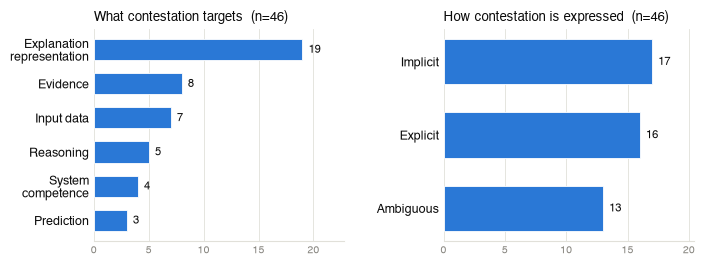


wrote taxonomy_distributions.pdf/.png (+ dist_*_reconciled.csv tables)


In [6]:
# ============================================================
# 6. Final taxonomy distributions (RECONCILED gold) + publication figure
# ============================================================
# These use the reconciled gold ("yes", n_yes above) computed in cell 5 above --
# NOT Notebook 04's dist_*.csv, which is the pre-reconciliation single-coder pass
# (47 "yes", target counts 17/9/8/6/4/3). Reconciliation (this notebook) changed
# the total to 49 and shifted category counts -- this cell is the number that
# should be reported and plotted in the paper.
(OUT / "tables").mkdir(exist_ok=True)
(OUT / "figures").mkdir(exist_ok=True)

def dist_gold(col):
    s = yes[col].dropna()
    return s[s != "n/a"].value_counts()

tax_gold = {}
for c in DIMS:
    vc = dist_gold(c).rename("episodes")
    tax_gold[c] = vc
    vc.to_frame().to_csv(OUT / "tables" / f"dist_{c}_reconciled.csv")
    print(f"{c}  (of {n_yes} reconciled contestation episodes):")
    display(vc.to_frame())

import matplotlib.pyplot as plt

BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK, "font.size": 9,
})

def barh_panel(ax, series, title):
    s = series.sort_values(ascending=True)
    ax.barh(s.index, s.values, color=BLUE, height=0.62, edgecolor="white",
             linewidth=0.6, zorder=3)
    for y, v in enumerate(s.values):
        ax.text(v + max(s.values) * 0.03, y, str(int(v)), va="center", ha="left",
                fontsize=8, color=INK)
    ax.set_title(title, fontsize=9.5, loc="left", color=INK, pad=6)
    ax.set_xlim(0, max(s.values) * 1.20)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0, labelsize=7.5)
    ax.xaxis.grid(True, color=GRID, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))

target_labels = {"explanation representation": "Explanation\nrepresentation",
                  "evidence": "Evidence", "input data": "Input data",
                  "reasoning": "Reasoning", "system competence": "System\ncompetence",
                  "prediction": "Prediction"}
barh_panel(axes[0], tax_gold["target"].rename(index=lambda k: target_labels.get(k, k)),
           f"What contestation targets  (n={n_yes})")
barh_panel(axes[1], tax_gold["presence"].rename(index=str.capitalize),
           f"How contestation is expressed  (n={n_yes})")

fig.tight_layout(pad=0.6, w_pad=2.6)
fig.savefig(OUT / "figures" / "taxonomy_distributions.pdf", bbox_inches="tight")
fig.savefig(OUT / "figures" / "taxonomy_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nwrote taxonomy_distributions.pdf/.png (+ dist_*_reconciled.csv tables)")

In [7]:
# ============================================================
# 7. Group x taxonomy-dimension crosstabs (test, don't assume, the
#    group-difference hypotheses in the paper's Findings 4.3)
# ============================================================
for dim in ["target", "grounds", "interaction_act"]:
    ct = pd.crosstab(yes["participant_group"], yes[dim]).reindex(index=groups, fill_value=0)
    ct.to_csv(OUT / "tables" / f"{dim}_by_group_reconciled.csv")
    print(f"\n{dim} by participant_group (row %):")
    display((ct.div(ct.sum(axis=1), axis=0) * 100).round(0).astype(int).assign(N=ct.sum(axis=1)))


target by participant_group (row %):


target,evidence,explanation representation,input data,prediction,reasoning,system competence,N
participant_group,,,,,,,
DE,19,31,12,12,12,12,16
IT,25,50,17,0,8,0,12
SSH,11,44,17,6,11,11,18



grounds by participant_group (row %):


grounds,causal implausibility,data-quality concern,domain knowledge,internal inconsistency,missing evidence,presentation ambiguity,prior experience,technical knowledge,N
participant_group,,,,,,,,,
DE,0,19,38,6,6,25,0,6,16
IT,0,0,17,0,50,17,8,8,12
SSH,11,11,11,0,6,28,6,28,18



interaction_act by participant_group (row %):


interaction_act,alternative proposal,correction,counterexample,direct challenge,rejection,request for justification,request to acknowledge uncertainty,N
participant_group,,,,,,,,
DE,12,6,6,31,12,25,6,16
IT,17,17,0,8,8,42,8,12
SSH,22,11,6,28,11,11,11,18


In [8]:
# ============================================================
# 8. Explanation-format x interaction-act crosstab (test the
#    "counterfactuals invite proposal-shaped contestation" hypothesis)
# ============================================================
ct = pd.crosstab(yes["explanation_format"], yes["interaction_act"]).reindex(index=formats, fill_value=0)
ct.to_csv(OUT / "tables" / "interaction_act_by_format_reconciled.csv")
display(ct.assign(N=ct.sum(axis=1)))

interaction_act,alternative proposal,correction,counterexample,direct challenge,rejection,request for justification,request to acknowledge uncertainty,N
explanation_format,,,,,,,,
Descriptive statistics,4,3,0,1,0,1,3,12
SHAP,3,0,1,3,1,3,0,11
LIME,0,1,1,1,1,2,0,6
Anchor,1,0,0,2,0,3,0,6
Counterfactual,0,1,0,4,3,2,1,11


## What this feeds in the paper

- **First-pass agreement** (Cohen's κ on the double-coded subset) → `sec:reliability` /
  `tab:irr`, reported honestly with the caveat that Coder 1 read the English
  translation and Coder 2 the original Polish.
- **Disagreement sources** (`disagreement_sources.csv`) → the reliability discussion
  and the error-analysis: most disagreements are *implicit / hidden* contestation,
  which motivates the "reliability stats can misfit interpretive coding" point and
  the detection error-analysis; one was a materials artifact (Coder 2's file lacked
  speaker labels); one was the target-vs-context unit rule.
- **`feasibility_review_sample_GOLD.csv`** is now the **reconciled gold standard** —
  it supersedes the single-coder file for the benchmark and all reported counts.
- The **gate still passes** on the reconciled gold: contestation stays the construct.

First-pass κ is modest — expected for an implicit, interpretive phenomenon on a
first independent pass. Report it plainly, show the sources, and lean the rigour
argument on the codebook + adjudication.